# Within-Subject Vote-Change Metrics

This notebook computes within-subject ranking change metrics between **pre-treatment** and **post-treatment** rankings.

Metrics computed per participant:
1. `top_choice_switch`
2. `any_edit`
3. `kendall_movement` (via Kendall's tau)
4. `footrule_distance_normalized`

It supports two common input layouts:
- Ordered lists (e.g., `['clinic', 'food', 'trees', 'animals']` or `'clinic > food > trees > animals'`)
- Separate rank columns (e.g., `clinic_pre_rank`, `clinic_post_rank`)


## Interpretation Notes

- **Top-choice switch** is a coarse binary indicator: it only checks whether rank 1 changed.
- **Any edit** is also binary, but checks whether any part of the ranking changed.
- **Kendall movement** and **normalized footrule distance** use the full ranking, so they are more sensitive to subtle reorderings.
- These are **within-subject change measures**. By themselves, they do not identify a causal treatment effect without an appropriate control/counterfactual design.


In [1]:
# Imports and setup
from pathlib import Path
import ast
import json

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 180)


## Configuration

Set your data path and parsing mode here.

`ranking_format` options:
- `'ordered_list_columns'`
- `'rank_columns'`


In [3]:
# ---------------------------
# User-configurable settings
# ---------------------------

# Primary input CSV (default points at analysis/output)
INPUT_CSV_PATH = Path('../output/phase2_participant_changes.csv')

# Optional fallback candidates for different notebook working directories
INPUT_CSV_CANDIDATES = [
    INPUT_CSV_PATH,
    Path('../output/phase2_participant_changes.csv'),
    Path('../../analysis/output/phase2_participant_changes.csv'),
]

# Output folder for notebook results
OUTPUT_DIR = Path('analysis/output/power_calc')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Column containing unique participant IDs
PARTICIPANT_ID_COL = 'user_id'

# Input format selector
ranking_format = 'ordered_list_columns'  # 'ordered_list_columns' or 'rank_columns'

# Ordered-list mode settings
ORDERED_LIST_PRE_COL = 'initial_ranking'
ORDERED_LIST_POST_COL = 'final_ranking'
ORDERED_LIST_SEPARATOR = '>'  # used when cells are delimiter strings

# Rank-columns mode settings
# Example expected naming: '<option>_pre_rank' and '<option>_post_rank'
OPTIONS = [
    'community_clinic',
    'food_pantry',
    'urban_tree',
    'animal_rescue',
]
PRE_RANK_SUFFIX = '_pre_rank'
POST_RANK_SUFFIX = '_post_rank'

# Validation behavior
ALLOW_MISSING_RANKS = False
STRICT_COMPLETE_PERMUTATION = True

# CI behavior for continuous metrics: 't' (recommended for modest n) or 'normal'
CONTINUOUS_CI_METHOD = 't'


## Helper Functions

In [4]:
def safe_parse_ordered_cell(cell, separator='>'):
    """Parse one ranking cell into an ordered list of options."""
    if isinstance(cell, list):
        return [str(x).strip() for x in cell]

    if pd.isna(cell):
        return None

    if isinstance(cell, (tuple, np.ndarray, pd.Series)):
        return [str(x).strip() for x in list(cell)]

    if isinstance(cell, str):
        s = cell.strip()
        if not s:
            return None

        if (s.startswith('[') and s.endswith(']')) or (s.startswith('(') and s.endswith(')')):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, (list, tuple)):
                    return [str(x).strip() for x in parsed]
            except Exception:
                pass

        if s.startswith('[') and s.endswith(']'):
            try:
                parsed = json.loads(s)
                if isinstance(parsed, list):
                    return [str(x).strip() for x in parsed]
            except Exception:
                pass

        if separator in s:
            return [part.strip() for part in s.split(separator) if part.strip()]

        if ',' in s:
            return [part.strip() for part in s.split(',') if part.strip()]

        return [s]

    return None


def parse_ranking(row, ranking_format, config):
    """Return (pre_order, post_order, notes, meta) for one row."""
    notes = []
    meta = {'pre_rank_values': None, 'post_rank_values': None}

    if ranking_format == 'ordered_list_columns':
        pre = safe_parse_ordered_cell(row.get(config['pre_col']), separator=config.get('separator', '>'))
        post = safe_parse_ordered_cell(row.get(config['post_col']), separator=config.get('separator', '>'))
        return pre, post, notes, meta

    if ranking_format == 'rank_columns':
        options = config['options']
        pre_suffix = config['pre_suffix']
        post_suffix = config['post_suffix']

        pre_pairs = []
        post_pairs = []
        pre_values = []
        post_values = []

        for opt in options:
            pre_col = f'{opt}{pre_suffix}'
            post_col = f'{opt}{post_suffix}'
            pre_val = row.get(pre_col)
            post_val = row.get(post_col)
            pre_pairs.append((opt, pre_val))
            post_pairs.append((opt, post_val))
            pre_values.append(pre_val)
            post_values.append(post_val)

        meta['pre_rank_values'] = pre_values
        meta['post_rank_values'] = post_values

        def build_order(pairs):
            try:
                clean = [(opt, float(rank)) for opt, rank in pairs if not pd.isna(rank)]
                clean_sorted = sorted(clean, key=lambda x: x[1])
                return [opt for opt, _ in clean_sorted]
            except Exception:
                return None

        pre = build_order(pre_pairs)
        post = build_order(post_pairs)
        return pre, post, notes, meta

    raise ValueError(f'Unsupported ranking_format: {ranking_format}')


def is_valid_permutation(ranks, allow_missing=False, strict_complete=True):
    """Check whether rank values form a valid permutation (optionally allowing missing)."""
    if ranks is None:
        return False, 'missing_ranks'

    ranks = list(ranks)
    if len(ranks) == 0:
        return False, 'empty_ranking'

    if any(pd.isna(x) for x in ranks):
        if not allow_missing:
            return False, 'missing_rank_value'

    non_missing = [x for x in ranks if not pd.isna(x)]

    try:
        int_ranks = [int(x) for x in non_missing]
    except Exception:
        return False, 'non_integer_rank_value'

    if len(set(int_ranks)) != len(int_ranks):
        return False, 'duplicated_rank_values'

    if strict_complete:
        J = len(int_ranks)
        expected = set(range(1, J + 1))
        if set(int_ranks) != expected:
            return False, 'ranks_not_complete_1_to_J'

    return True, None


def validate_ranking_row(participant_id, pre_order, post_order, allow_missing=False, strict_complete=True, pre_rank_values=None, post_rank_values=None):
    """Validate one participant's pre/post rankings. Return (is_valid, reasons)."""
    reasons = []

    if pre_order is None or post_order is None:
        reasons.append('missing_pre_or_post_ranking')
        return False, reasons

    if len(pre_order) == 0 or len(post_order) == 0:
        reasons.append('empty_pre_or_post_ranking')
        return False, reasons

    pre_set = set(pre_order)
    post_set = set(post_order)
    if pre_set != post_set:
        reasons.append('pre_post_option_sets_do_not_match')

    if len(pre_order) != len(pre_set):
        reasons.append('duplicate_option_in_pre_order')

    if len(post_order) != len(post_set):
        reasons.append('duplicate_option_in_post_order')

    # If raw rank vectors are available (rank-column mode), validate them directly.
    if pre_rank_values is not None:
        ok_pre_raw, reason_pre_raw = is_valid_permutation(pre_rank_values, allow_missing=allow_missing, strict_complete=strict_complete)
        if not ok_pre_raw and reason_pre_raw:
            reasons.append(f'pre_invalid_rank_values:{reason_pre_raw}')

    if post_rank_values is not None:
        ok_post_raw, reason_post_raw = is_valid_permutation(post_rank_values, allow_missing=allow_missing, strict_complete=strict_complete)
        if not ok_post_raw and reason_post_raw:
            reasons.append(f'post_invalid_rank_values:{reason_post_raw}')

    # For parsed orders, implied ranks must also be valid.
    pre_ranks = list(range(1, len(pre_order) + 1))
    post_ranks = list(range(1, len(post_order) + 1))

    ok_pre, reason_pre = is_valid_permutation(pre_ranks, allow_missing=allow_missing, strict_complete=strict_complete)
    ok_post, reason_post = is_valid_permutation(post_ranks, allow_missing=allow_missing, strict_complete=strict_complete)

    if not ok_pre and reason_pre:
        reasons.append(f'pre_invalid_permutation:{reason_pre}')
    if not ok_post and reason_post:
        reasons.append(f'post_invalid_permutation:{reason_post}')

    return len(reasons) == 0, reasons


def aligned_rank_vectors(pre_order, post_order):
    """Build aligned rank vectors using pre_order option sequence as canonical alignment."""
    option_order = list(pre_order)
    pre_rank_map = {opt: i + 1 for i, opt in enumerate(pre_order)}
    post_rank_map = {opt: i + 1 for i, opt in enumerate(post_order)}

    pre_ranks = np.array([pre_rank_map[opt] for opt in option_order], dtype=float)
    post_ranks = np.array([post_rank_map[opt] for opt in option_order], dtype=float)
    return option_order, pre_ranks, post_ranks


def compute_kendall_movement(pre_ranks, post_ranks):
    """Return (kendall_tau, kendall_movement, note)."""
    try:
        tau, _ = stats.kendalltau(pre_ranks, post_ranks)
        if tau is None or np.isnan(tau):
            return np.nan, np.nan, 'kendall_tau_nan'
        movement = (1 - tau) / 2
        return float(tau), float(movement), None
    except Exception as exc:
        return np.nan, np.nan, f'kendall_error:{exc}'


def max_footrule_distance(J):
    """Compute max Spearman footrule distance for J ranked options."""
    if J <= 1:
        return 0.0
    ranks = np.arange(1, J + 1)
    reversed_ranks = ranks[::-1]
    return float(np.abs(ranks - reversed_ranks).sum())


def compute_footrule_distance(pre_ranks, post_ranks):
    """Return (footrule_distance, normalized_footrule_distance)."""
    footrule = float(np.abs(pre_ranks - post_ranks).sum())
    J = len(pre_ranks)
    max_foot = max_footrule_distance(J)
    if max_foot == 0:
        return footrule, np.nan
    return footrule, footrule / max_foot


def wilson_interval(successes, n, confidence=0.95):
    """Wilson score interval for a binomial proportion."""
    if n == 0:
        return np.nan, np.nan
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    p_hat = successes / n
    denom = 1 + (z**2 / n)
    center = (p_hat + (z**2 / (2 * n))) / denom
    half = (z / denom) * np.sqrt((p_hat * (1 - p_hat) / n) + (z**2 / (4 * n**2)))
    return float(max(0, center - half)), float(min(1, center + half))


def summarize_binary_metric(series, confidence=0.95):
    """Summarize binary metric with Wilson CI."""
    s = series.dropna().astype(int)
    n = int(s.shape[0])
    successes = int(s.sum())
    share = (successes / n) if n else np.nan
    lo, hi = wilson_interval(successes, n, confidence=confidence)
    return {
        'n': n,
        'successes': successes,
        'share': share,
        'ci_method': 'wilson',
        'ci_low': lo,
        'ci_high': hi,
    }


def summarize_continuous_metric(series, confidence=0.95, method='t'):
    """Summarize continuous metric with CI for the mean."""
    s = series.dropna().astype(float)
    n = int(s.shape[0])

    out = {
        'n': n,
        'mean': np.nan,
        'sd': np.nan,
        'median': np.nan,
        'min': np.nan,
        'max': np.nan,
        'ci_method': method,
        'ci_low': np.nan,
        'ci_high': np.nan,
    }

    if n == 0:
        return out

    mean = float(s.mean())
    sd = float(s.std(ddof=1)) if n > 1 else np.nan

    out.update({
        'mean': mean,
        'sd': sd,
        'median': float(s.median()),
        'min': float(s.min()),
        'max': float(s.max()),
    })

    if n == 1:
        return out

    se = sd / np.sqrt(n)
    alpha = 1 - confidence

    if method == 'normal':
        z = stats.norm.ppf(1 - alpha / 2)
        out['ci_low'] = float(mean - z * se)
        out['ci_high'] = float(mean + z * se)
        out['ci_method'] = 'normal_approximation'
    else:
        tcrit = stats.t.ppf(1 - alpha / 2, df=n - 1)
        out['ci_low'] = float(mean - tcrit * se)
        out['ci_high'] = float(mean + tcrit * se)
        out['ci_method'] = 't_based'

    return out


## Load Data

If the configured file does not exist, this cell creates a small toy dataset so you can test immediately.


In [5]:
def make_toy_data_ordered_list():
    return pd.DataFrame([
        {'user_id': 'p1', 'initial_ranking': 'clinic > food > trees > animals', 'final_ranking': 'clinic > food > trees > animals'},
        {'user_id': 'p2', 'initial_ranking': 'clinic > food > trees > animals', 'final_ranking': 'food > clinic > trees > animals'},
        {'user_id': 'p3', 'initial_ranking': 'animals > trees > food > clinic', 'final_ranking': 'clinic > food > trees > animals'},
        {'user_id': 'p_bad_missing_post', 'initial_ranking': 'clinic > food > trees > animals', 'final_ranking': np.nan},
        {'user_id': 'p_bad_dup_option', 'initial_ranking': 'clinic > clinic > trees > animals', 'final_ranking': 'clinic > food > trees > animals'},
    ])


def resolve_first_existing(candidates):
    for candidate in candidates:
        p = Path(candidate)
        if p.exists():
            return p
    return None


resolved_input = resolve_first_existing(INPUT_CSV_CANDIDATES)
print('Current working directory:', Path.cwd())

if resolved_input is not None:
    df_raw = pd.read_csv(resolved_input)
    print(f'Loaded data from {resolved_input} with shape={df_raw.shape}')
else:
    print('WARNING: No input CSV found in any configured candidate path. Using toy example data.')
    print('Tried:')
    for c in INPUT_CSV_CANDIDATES:
        print(' -', Path(c))
    df_raw = make_toy_data_ordered_list()

print('Columns:', list(df_raw.columns))
display(df_raw.head())


Current working directory: /Users/szelkovica/Documents/GitHub/harmonica-mcp-experiments/analysis/power_calc
Loaded data from ../output/phase2_participant_changes.csv with shape=(18, 7)
Columns: ['user_id', 'initial_top_choice', 'final_top_choice', 'changed_top_choice', 'footrule_distance', 'initial_ranking', 'final_ranking']


,user_id,initial_top_choice,final_top_choice,changed_top_choice,footrule_distance,initial_ranking,final_ranking
0,3c5387b0da49,community_clinic,community_clinic,False,0,community_clinic > food_pantry > urban_tree > animal_rescue,community_clinic > food_pantry > urban_tree > animal_rescue
1,9d9c3d6a7d9c,food_pantry,food_pantry,False,2,food_pantry > community_clinic > animal_rescue > urban_tree,food_pantry > community_clinic > urban_tree > animal_rescue
2,e384b04afce3,community_clinic,community_clinic,False,0,community_clinic > food_pantry > animal_rescue > urban_tree,community_clinic > food_pantry > animal_rescue > urban_tree
3,f80d4f54b108,community_clinic,community_clinic,False,0,community_clinic > food_pantry > animal_rescue > urban_tree,community_clinic > food_pantry > animal_rescue > urban_tree
4,61fecb490ab2,animal_rescue,animal_rescue,False,0,animal_rescue > urban_tree > community_clinic > food_pantry,animal_rescue > urban_tree > community_clinic > food_pantry


## Parse, Validate, and Standardize Rankings

In [6]:
parse_config = {
    'pre_col': ORDERED_LIST_PRE_COL,
    'post_col': ORDERED_LIST_POST_COL,
    'separator': ORDERED_LIST_SEPARATOR,
    'options': OPTIONS,
    'pre_suffix': PRE_RANK_SUFFIX,
    'post_suffix': POST_RANK_SUFFIX,
}

records = []
excluded = []

for _, row in df_raw.iterrows():
    participant_id = row.get(PARTICIPANT_ID_COL)

    pre_order, post_order, parse_notes, parse_meta = parse_ranking(
        row=row,
        ranking_format=ranking_format,
        config=parse_config,
    )

    is_valid, reasons = validate_ranking_row(
        participant_id=participant_id,
        pre_order=pre_order,
        post_order=post_order,
        allow_missing=ALLOW_MISSING_RANKS,
        strict_complete=STRICT_COMPLETE_PERMUTATION,
        pre_rank_values=parse_meta.get('pre_rank_values'),
        post_rank_values=parse_meta.get('post_rank_values'),
    )

    all_notes = list(parse_notes)

    if not is_valid:
        excluded.append({
            'participant_id': participant_id,
            'reason': ';'.join(reasons),
            'pre_order_raw': pre_order,
            'post_order_raw': post_order,
        })
        continue

    option_order, pre_ranks, post_ranks = aligned_rank_vectors(pre_order, post_order)

    if np.isnan(pre_ranks).any() or np.isnan(post_ranks).any():
        excluded.append({
            'participant_id': participant_id,
            'reason': 'nan_in_aligned_rank_vectors',
            'pre_order_raw': pre_order,
            'post_order_raw': post_order,
        })
        continue

    records.append({
        'participant_id': participant_id,
        'pre_order': pre_order,
        'post_order': post_order,
        'option_order': option_order,
        'pre_ranks': pre_ranks.tolist(),
        'post_ranks': post_ranks.tolist(),
        'notes': ';'.join(all_notes) if all_notes else '',
    })

results_base_df = pd.DataFrame(records)
excluded_df = pd.DataFrame(excluded)

print(f'N included: {len(results_base_df)}')
print(f'N excluded: {len(excluded_df)}')

if len(excluded_df) > 0:
    print('\nExcluded row summary (compact):')
    display(excluded_df['reason'].value_counts().rename_axis('reason').reset_index(name='n'))
    display(excluded_df.head())

display(results_base_df.head())


N included: 18
N excluded: 0


,participant_id,pre_order,post_order,option_order,pre_ranks,post_ranks,notes
0,3c5387b0da49,"[community_clinic, food_pantry, urban_tree, animal_rescue]","[community_clinic, food_pantry, urban_tree, animal_rescue]","[community_clinic, food_pantry, urban_tree, animal_rescue]","[1.0, 2.0, 3.0, 4.0]","[1.0, 2.0, 3.0, 4.0]",
1,9d9c3d6a7d9c,"[food_pantry, community_clinic, animal_rescue, urban_tree]","[food_pantry, community_clinic, urban_tree, animal_rescue]","[food_pantry, community_clinic, animal_rescue, urban_tree]","[1.0, 2.0, 3.0, 4.0]","[1.0, 2.0, 4.0, 3.0]",
2,e384b04afce3,"[community_clinic, food_pantry, animal_rescue, urban_tree]","[community_clinic, food_pantry, animal_rescue, urban_tree]","[community_clinic, food_pantry, animal_rescue, urban_tree]","[1.0, 2.0, 3.0, 4.0]","[1.0, 2.0, 3.0, 4.0]",
3,f80d4f54b108,"[community_clinic, food_pantry, animal_rescue, urban_tree]","[community_clinic, food_pantry, animal_rescue, urban_tree]","[community_clinic, food_pantry, animal_rescue, urban_tree]","[1.0, 2.0, 3.0, 4.0]","[1.0, 2.0, 3.0, 4.0]",
4,61fecb490ab2,"[animal_rescue, urban_tree, community_clinic, food_pantry]","[animal_rescue, urban_tree, community_clinic, food_pantry]","[animal_rescue, urban_tree, community_clinic, food_pantry]","[1.0, 2.0, 3.0, 4.0]","[1.0, 2.0, 3.0, 4.0]",


## Compute Participant-Level Metrics

In [7]:
metric_rows = []

for _, row in results_base_df.iterrows():
    pre_order = row['pre_order']
    post_order = row['post_order']
    pre_ranks = np.array(row['pre_ranks'], dtype=float)
    post_ranks = np.array(row['post_ranks'], dtype=float)

    top_choice_switch = int(pre_order[0] != post_order[0])
    any_edit = int(pre_order != post_order)

    kendall_tau, kendall_movement, kendall_note = compute_kendall_movement(pre_ranks, post_ranks)
    footrule_distance, footrule_norm = compute_footrule_distance(pre_ranks, post_ranks)

    notes = row.get('notes', '')
    if kendall_note:
        notes = ';'.join([x for x in [notes, kendall_note] if x])

    metric_rows.append({
        'participant_id': row['participant_id'],
        'pre_order': pre_order,
        'post_order': post_order,
        'top_choice_switch': top_choice_switch,
        'any_edit': any_edit,
        'kendall_tau': kendall_tau,
        'kendall_movement': kendall_movement,
        'footrule_distance': footrule_distance,
        'footrule_distance_normalized': footrule_norm,
        'notes': notes,
    })

participant_metrics_df = pd.DataFrame(metric_rows)
display(participant_metrics_df.head())


,participant_id,pre_order,post_order,top_choice_switch,any_edit,kendall_tau,kendall_movement,footrule_distance,footrule_distance_normalized,notes
0,3c5387b0da49,"[community_clinic, food_pantry, urban_tree, animal_rescue]","[community_clinic, food_pantry, urban_tree, animal_rescue]",0,0,1.000000,0.000000,0.0,0.00,
1,9d9c3d6a7d9c,"[food_pantry, community_clinic, animal_rescue, urban_tree]","[food_pantry, community_clinic, urban_tree, animal_rescue]",0,1,0.666667,0.166667,2.0,0.25,
2,e384b04afce3,"[community_clinic, food_pantry, animal_rescue, urban_tree]","[community_clinic, food_pantry, animal_rescue, urban_tree]",0,0,1.000000,0.000000,0.0,0.00,
3,f80d4f54b108,"[community_clinic, food_pantry, animal_rescue, urban_tree]","[community_clinic, food_pantry, animal_rescue, urban_tree]",0,0,1.000000,0.000000,0.0,0.00,
4,61fecb490ab2,"[animal_rescue, urban_tree, community_clinic, food_pantry]","[animal_rescue, urban_tree, community_clinic, food_pantry]",0,0,1.000000,0.000000,0.0,0.00,


## Sample-Level Summary and 95% Confidence Intervals

In [8]:
summary = {
    'n_included': int(len(participant_metrics_df)),
    'n_excluded': int(len(excluded_df)),
}

for col in ['top_choice_switch', 'any_edit']:
    summary[col] = summarize_binary_metric(participant_metrics_df[col], confidence=0.95)

for col in ['kendall_movement', 'footrule_distance_normalized']:
    summary[col] = summarize_continuous_metric(
        participant_metrics_df[col],
        confidence=0.95,
        method=CONTINUOUS_CI_METHOD,
    )

print('Summary (human-readable):')
print(f"N included: {summary['n_included']}")
print(f"N excluded: {summary['n_excluded']}")

for b in ['top_choice_switch', 'any_edit']:
    s = summary[b]
    print(
        f"{b}: share={s['share']:.3f} ({s['successes']}/{s['n']}), "
        f"95% CI [{s['ci_low']:.3f}, {s['ci_high']:.3f}] via {s['ci_method']}"
    )

for c in ['kendall_movement', 'footrule_distance_normalized']:
    s = summary[c]
    print(
        f"{c}: mean={s['mean']:.3f}, sd={s['sd']:.3f}, median={s['median']:.3f}, "
        f"min={s['min']:.3f}, max={s['max']:.3f}, "
        f"95% mean CI [{s['ci_low']:.3f}, {s['ci_high']:.3f}] via {s['ci_method']}"
    )

summary_df = pd.DataFrame([
    {'metric': 'n_included', 'value': summary['n_included']},
    {'metric': 'n_excluded', 'value': summary['n_excluded']},
])

for b in ['top_choice_switch', 'any_edit']:
    s = summary[b]
    summary_df = pd.concat([
        summary_df,
        pd.DataFrame([
            {'metric': b, 'value': s['share']},
            {'metric': f'{b}_n', 'value': s['n']},
            {'metric': f'{b}_successes', 'value': s['successes']},
            {'metric': f'{b}_ci_low', 'value': s['ci_low']},
            {'metric': f'{b}_ci_high', 'value': s['ci_high']},
            {'metric': f'{b}_ci_method', 'value': s['ci_method']},
        ])
    ], ignore_index=True)

for c in ['kendall_movement', 'footrule_distance_normalized']:
    s = summary[c]
    summary_df = pd.concat([
        summary_df,
        pd.DataFrame([
            {'metric': f'{c}_n', 'value': s['n']},
            {'metric': f'{c}_mean', 'value': s['mean']},
            {'metric': f'{c}_sd', 'value': s['sd']},
            {'metric': f'{c}_median', 'value': s['median']},
            {'metric': f'{c}_min', 'value': s['min']},
            {'metric': f'{c}_max', 'value': s['max']},
            {'metric': f'{c}_ci_low', 'value': s['ci_low']},
            {'metric': f'{c}_ci_high', 'value': s['ci_high']},
            {'metric': f'{c}_ci_method', 'value': s['ci_method']},
        ])
    ], ignore_index=True)

summary_df.head(20)


Summary (human-readable):
N included: 18
N excluded: 0
top_choice_switch: share=0.222 (4/18), 95% CI [0.090, 0.452] via wilson
any_edit: share=0.444 (8/18), 95% CI [0.246, 0.663] via wilson
kendall_movement: mean=0.093, sd=0.117, median=0.000, min=0.000, max=0.333, 95% mean CI [0.034, 0.151] via t_based
footrule_distance_normalized: mean=0.139, sd=0.176, median=0.000, min=0.000, max=0.500, 95% mean CI [0.051, 0.227] via t_based


,metric,value
0,n_included,18
1,n_excluded,0
2,top_choice_switch,0.222222
3,top_choice_switch_n,18
4,top_choice_switch_successes,4
5,top_choice_switch_ci_low,0.090009
6,top_choice_switch_ci_high,0.452146
7,top_choice_switch_ci_method,wilson
8,any_edit,0.444444
9,any_edit_n,18


## Simple Visualizations

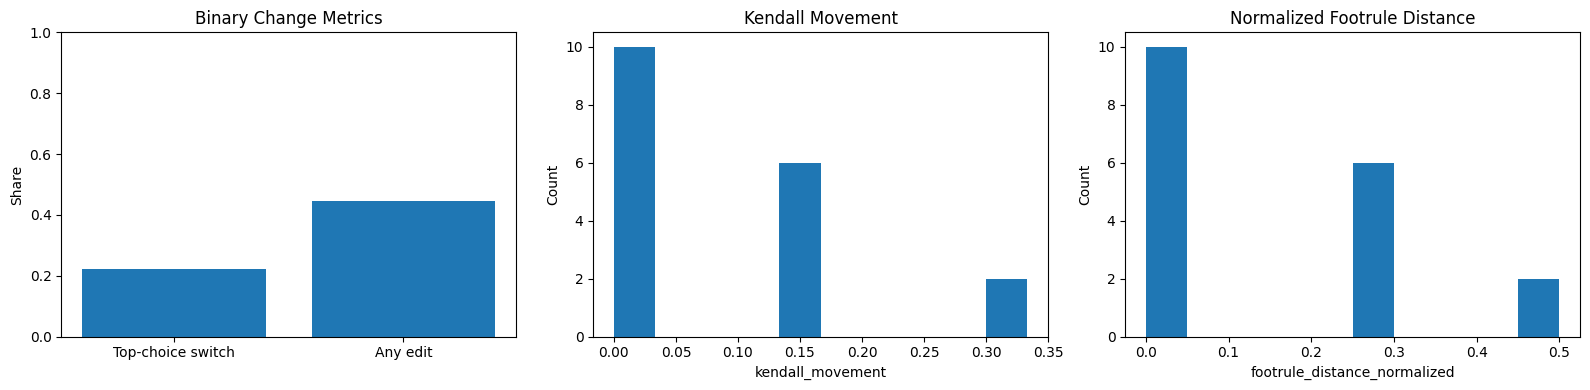

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

binary_shares = {
    'Top-choice switch': participant_metrics_df['top_choice_switch'].mean(),
    'Any edit': participant_metrics_df['any_edit'].mean(),
}
axes[0].bar(list(binary_shares.keys()), list(binary_shares.values()))
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Share')
axes[0].set_title('Binary Change Metrics')

axes[1].hist(participant_metrics_df['kendall_movement'].dropna(), bins=10)
axes[1].set_title('Kendall Movement')
axes[1].set_xlabel('kendall_movement')
axes[1].set_ylabel('Count')

axes[2].hist(participant_metrics_df['footrule_distance_normalized'].dropna(), bins=10)
axes[2].set_title('Normalized Footrule Distance')
axes[2].set_xlabel('footrule_distance_normalized')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()


## Optional Pairwise Inspection (Sanity Checks)

This section prints example participants for:
- unchanged ranking
- changed top choice
- small movement
- large movement


In [10]:
def first_row_or_none(df):
    if df.shape[0] == 0:
        return None
    return df.iloc[0]

examples = {
    'unchanged_ranking': first_row_or_none(participant_metrics_df[participant_metrics_df['any_edit'] == 0]),
    'changed_top_choice': first_row_or_none(participant_metrics_df[participant_metrics_df['top_choice_switch'] == 1]),
    'small_movement': first_row_or_none(participant_metrics_df.sort_values('kendall_movement', ascending=True)),
    'large_movement': first_row_or_none(participant_metrics_df.sort_values('kendall_movement', ascending=False)),
}

for label, ex in examples.items():
    print(f'\n--- {label} ---')
    if ex is None:
        print('No example available.')
    else:
        display(pd.DataFrame([ex]))



--- unchanged_ranking ---


,participant_id,pre_order,post_order,top_choice_switch,any_edit,kendall_tau,kendall_movement,footrule_distance,footrule_distance_normalized,notes
0,3c5387b0da49,"[community_clinic, food_pantry, urban_tree, animal_rescue]","[community_clinic, food_pantry, urban_tree, animal_rescue]",0,0,1.0,0.0,0.0,0.0,



--- changed_top_choice ---


,participant_id,pre_order,post_order,top_choice_switch,any_edit,kendall_tau,kendall_movement,footrule_distance,footrule_distance_normalized,notes
5,ad571f253120,"[food_pantry, community_clinic, animal_rescue, urban_tree]","[community_clinic, food_pantry, animal_rescue, urban_tree]",1,1,0.666667,0.166667,2.0,0.25,



--- small_movement ---


,participant_id,pre_order,post_order,top_choice_switch,any_edit,kendall_tau,kendall_movement,footrule_distance,footrule_distance_normalized,notes
0,3c5387b0da49,"[community_clinic, food_pantry, urban_tree, animal_rescue]","[community_clinic, food_pantry, urban_tree, animal_rescue]",0,0,1.0,0.0,0.0,0.0,



--- large_movement ---


,participant_id,pre_order,post_order,top_choice_switch,any_edit,kendall_tau,kendall_movement,footrule_distance,footrule_distance_normalized,notes
11,8d4b92f5ba5d,"[animal_rescue, food_pantry, community_clinic, urban_tree]","[community_clinic, animal_rescue, food_pantry, urban_tree]",1,1,0.333333,0.333333,4.0,0.5,


## Reasoning Metrics (Reuse Saved Outputs)

This section reuses saved reasoning outputs from `analysis/output` instead of recomputing embeddings when possible.

Added participant-level reasoning columns:
- `embedding_cosine_similarity`
- `embedding_shift_intensity`
- `directional_learning_centroid`
- `directional_learning_nearest_exposed`


In [11]:
# Reasoning input files (reused outputs)
REASONING_SHIFT_CSV = Path('../output/phase2_reasoning_embedding_shift.csv')
PHASE1_REASONING_EMBEDDINGS_JSON = Path('../output/phase1_reasoning_embeddings.json')
PHASE1_REASONING_VECTORS_JSON = Path('../output/phase1_reasoning_embedding_vectors.json')
PHASE2_REASONING_VECTORS_JSON = Path('../output/phase2_reasoning_embedding_vectors.json')

EXPOSED_USER_IDS = {
    'b026ba9960d8',
    '1e126bb5b77b',
    '855d390cfc05',
    '200b564596b2',
    'a3ffe8f27d1d',
    '2f999d554903',
}


def read_json(path):
    with open(path, 'r') as f:
        return json.load(f)


def as_vector(value):
    """Convert embedding payload to 1D numpy vector; return None if invalid."""
    if value is None:
        return None

    if isinstance(value, str):
        s = value.strip()
        if not s:
            return None
        try:
            value = json.loads(s)
        except Exception:
            try:
                value = ast.literal_eval(s)
            except Exception:
                return None

    if isinstance(value, list):
        try:
            vec = np.asarray(value, dtype=float)
        except Exception:
            return None
        if vec.ndim != 1 or vec.size == 0:
            return None
        return vec

    return None


def cosine_np(a, b):
    """Cosine similarity for 1D vectors; returns NaN if invalid."""
    if a is None or b is None:
        return np.nan
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return np.nan
    return float(np.dot(a, b) / denom)


def extract_exposed_embeddings():
    """Load phase1 exposed embeddings filtered to the specified exposed user IDs."""
    rows_out = []

    # Try primary path requested by user first.
    if PHASE1_REASONING_EMBEDDINGS_JSON.exists():
        payload = read_json(PHASE1_REASONING_EMBEDDINGS_JSON)
        if isinstance(payload, list):
            for row in payload:
                if not isinstance(row, dict):
                    continue
                uid = row.get('user_id')
                if uid not in EXPOSED_USER_IDS:
                    continue
                vec = as_vector(row.get('embedding') or row.get('initial_embedding'))
                if vec is not None:
                    rows_out.append({'user_id': uid, 'embedding': vec})
        elif isinstance(payload, dict):
            # Support schema variants if vectors are nested in this file.
            nested = payload.get('embedding_vectors') or payload.get('vectors') or []
            if isinstance(nested, list):
                for row in nested:
                    if not isinstance(row, dict):
                        continue
                    uid = row.get('user_id')
                    if uid not in EXPOSED_USER_IDS:
                        continue
                    vec = as_vector(row.get('embedding') or row.get('initial_embedding'))
                    if vec is not None:
                        rows_out.append({'user_id': uid, 'embedding': vec})

    # Fallback to dedicated vectors file if needed.
    if not rows_out and PHASE1_REASONING_VECTORS_JSON.exists():
        payload = read_json(PHASE1_REASONING_VECTORS_JSON)
        if isinstance(payload, list):
            for row in payload:
                if not isinstance(row, dict):
                    continue
                uid = row.get('user_id')
                if uid not in EXPOSED_USER_IDS:
                    continue
                vec = as_vector(row.get('embedding') or row.get('initial_embedding'))
                if vec is not None:
                    rows_out.append({'user_id': uid, 'embedding': vec})

    # Deduplicate by user_id (keep first seen)
    dedup = {}
    for row in rows_out:
        uid = row['user_id']
        if uid not in dedup:
            dedup[uid] = row

    return list(dedup.values())


def load_phase2_pre_post_vectors():
    """Load participant pre/post reasoning embeddings for directional metrics."""
    out = {}
    if not PHASE2_REASONING_VECTORS_JSON.exists():
        return out

    payload = read_json(PHASE2_REASONING_VECTORS_JSON)
    if not isinstance(payload, list):
        return out

    for row in payload:
        if not isinstance(row, dict):
            continue
        pid = row.get('user_id')
        if pid is None:
            continue
        pre_vec = as_vector(row.get('initial_embedding'))
        post_vec = as_vector(row.get('final_embedding'))
        if pre_vec is None or post_vec is None:
            continue
        out[pid] = {'pre': pre_vec, 'post': post_vec}
    return out


# 1) Reuse precomputed self-to-self movement outputs from phase 2 shift CSV.
if REASONING_SHIFT_CSV.exists():
    reasoning_shift_df = pd.read_csv(REASONING_SHIFT_CSV)
    reasoning_metrics_df = reasoning_shift_df[['user_id', 'embedding_cosine_similarity', 'embedding_shift_intensity']].copy()
    reasoning_metrics_df = reasoning_metrics_df.rename(columns={'user_id': 'participant_id'})
else:
    print(f'WARNING: {REASONING_SHIFT_CSV} not found. Reasoning movement columns will be NaN.')
    reasoning_metrics_df = pd.DataFrame(columns=['participant_id', 'embedding_cosine_similarity', 'embedding_shift_intensity'])

# 2) Compute directional learning metrics using saved embeddings.
exposed_rows = extract_exposed_embeddings()
phase2_vectors = load_phase2_pre_post_vectors()

if exposed_rows:
    exposed_matrix = np.vstack([row['embedding'] for row in exposed_rows])
    exposed_user_ids_order = [row['user_id'] for row in exposed_rows]
    exposed_centroid = exposed_matrix.mean(axis=0)
else:
    exposed_matrix = None
    exposed_user_ids_order = []
    exposed_centroid = None

if not exposed_rows:
    print('WARNING: No usable phase1 exposed embeddings found for specified exposed IDs; directional metrics set to NaN.')
if not phase2_vectors:
    print('WARNING: No usable phase2 pre/post vectors found; directional metrics set to NaN.')

print('Exposed IDs requested:', sorted(EXPOSED_USER_IDS))
print('Exposed embeddings loaded:', exposed_user_ids_order)

directional_rows = []
for pid, pair in phase2_vectors.items():
    pre_vec = pair['pre']
    post_vec = pair['post']

    pre_centroid = cosine_np(pre_vec, exposed_centroid) if exposed_centroid is not None else np.nan
    post_centroid = cosine_np(post_vec, exposed_centroid) if exposed_centroid is not None else np.nan
    directional_centroid = post_centroid - pre_centroid if not (np.isnan(post_centroid) or np.isnan(pre_centroid)) else np.nan

    # Nearest-exposed directional change anchored to pre: find s* = argmax_s cos(pre, s),
    # then compute cos(post, s*) - cos(pre, s*).
    if exposed_matrix is not None:
        pre_all = np.array([cosine_np(pre_vec, ex) for ex in exposed_matrix], dtype=float)
        valid_idx = np.where(~np.isnan(pre_all))[0]
        if valid_idx.size > 0:
            best_idx = int(valid_idx[np.argmax(pre_all[valid_idx])])
            anchor_vec = exposed_matrix[best_idx]
            anchor_uid = exposed_user_ids_order[best_idx]

            pre_anchor = cosine_np(pre_vec, anchor_vec)
            post_anchor = cosine_np(post_vec, anchor_vec)
            directional_nearest = post_anchor - pre_anchor if not (np.isnan(post_anchor) or np.isnan(pre_anchor)) else np.nan
        else:
            anchor_uid = None
            pre_anchor = np.nan
            post_anchor = np.nan
            directional_nearest = np.nan
    else:
        anchor_uid = None
        pre_anchor = np.nan
        post_anchor = np.nan
        directional_nearest = np.nan

    directional_rows.append({
        'participant_id': pid,
        'pre_to_exposed_centroid_cosine': pre_centroid,
        'post_to_exposed_centroid_cosine': post_centroid,
        'directional_learning_centroid': directional_centroid,
        'nearest_exposed_anchor_user_id': anchor_uid,
        'pre_to_nearest_exposed_cosine': pre_anchor,
        'post_to_nearest_exposed_cosine': post_anchor,
        'directional_learning_nearest_exposed': directional_nearest,
    })

directional_df = pd.DataFrame(directional_rows)

# 3) Merge into participant-level vote-change results.
participant_metrics_df = participant_metrics_df.merge(reasoning_metrics_df, on='participant_id', how='left')
participant_metrics_df = participant_metrics_df.merge(directional_df, on='participant_id', how='left')

print('Reasoning merge complete.')
print('N participants with embedding_shift_intensity:', participant_metrics_df['embedding_shift_intensity'].notna().sum())
print('N participants with directional_learning_centroid:', participant_metrics_df['directional_learning_centroid'].notna().sum())
print('N participants with directional_learning_nearest_exposed:', participant_metrics_df['directional_learning_nearest_exposed'].notna().sum())

cols_preview = [
    'participant_id',
    'embedding_cosine_similarity',
    'embedding_shift_intensity',
    'directional_learning_centroid',
    'nearest_exposed_anchor_user_id',
    'directional_learning_nearest_exposed',
]
display(participant_metrics_df[cols_preview].head())


Exposed IDs requested: ['1e126bb5b77b', '200b564596b2', '2f999d554903', '855d390cfc05', 'a3ffe8f27d1d', 'b026ba9960d8']
Exposed embeddings loaded: ['b026ba9960d8', '1e126bb5b77b', '855d390cfc05', '200b564596b2', 'a3ffe8f27d1d', '2f999d554903']
Reasoning merge complete.
N participants with embedding_shift_intensity: 18
N participants with directional_learning_centroid: 18
N participants with directional_learning_nearest_exposed: 18


,participant_id,embedding_cosine_similarity,embedding_shift_intensity,directional_learning_centroid,nearest_exposed_anchor_user_id,directional_learning_nearest_exposed
0,3c5387b0da49,0.553706,0.446294,-0.241073,a3ffe8f27d1d,-0.265564
1,9d9c3d6a7d9c,0.810818,0.189182,0.053697,855d390cfc05,0.057573
2,e384b04afce3,0.617336,0.382664,-0.222661,a3ffe8f27d1d,-0.344687
3,f80d4f54b108,0.506131,0.493869,-0.275320,a3ffe8f27d1d,-0.377874
4,61fecb490ab2,0.780987,0.219013,-0.020709,a3ffe8f27d1d,-0.062467


## Reasoning Summary (Reused + Directional Metrics)

- `embedding_cosine_similarity` is pre/post semantic similarity for each participant's own reasoning.
- `embedding_shift_intensity = 1 - embedding_cosine_similarity` is self-to-self semantic movement.
- `directional_learning_centroid` measures movement toward (positive) or away from (negative) the exposed-summary centroid.
- `directional_learning_nearest_exposed` measures movement toward (positive) or away from (negative) the most similar exposed summary.


In [13]:
reasoning_metrics_for_summary = [
    'embedding_shift_intensity',
    'embedding_cosine_similarity',
    'directional_learning_centroid',
    'directional_learning_nearest_exposed',
]

print('Reasoning summary (continuous metrics with 95% CI for mean):')
for col in reasoning_metrics_for_summary:
    stats_row = summarize_continuous_metric(
        participant_metrics_df[col],
        confidence=0.95,
        method=CONTINUOUS_CI_METHOD,
    )
    summary[col] = stats_row

    print(
        f"{col}: N={stats_row['n']}, mean={stats_row['mean']:.3f}, sd={stats_row['sd']:.3f}, "
        f"median={stats_row['median']:.3f}, min={stats_row['min']:.3f}, max={stats_row['max']:.3f}, "
        f"95% mean CI [{stats_row['ci_low']:.3f}, {stats_row['ci_high']:.3f}] via {stats_row['ci_method']}"
    )

# Append reasoning stats to summary_df so exports include them.
for col in reasoning_metrics_for_summary:
    s = summary[col]
    summary_df = pd.concat([
        summary_df,
        pd.DataFrame([
            {'metric': f'{col}_n', 'value': s['n']},
            {'metric': f'{col}_mean', 'value': s['mean']},
            {'metric': f'{col}_sd', 'value': s['sd']},
            {'metric': f'{col}_median', 'value': s['median']},
            {'metric': f'{col}_min', 'value': s['min']},
            {'metric': f'{col}_max', 'value': s['max']},
            {'metric': f'{col}_ci_low', 'value': s['ci_low']},
            {'metric': f'{col}_ci_high', 'value': s['ci_high']},
            {'metric': f'{col}_ci_method', 'value': s['ci_method']},
        ])
    ], ignore_index=True)

summary_df.tail(20)


Reasoning summary (continuous metrics with 95% CI for mean):
embedding_shift_intensity: N=18, mean=0.370, sd=0.101, median=0.367, min=0.189, max=0.514, 95% mean CI [0.320, 0.420] via t_based
embedding_cosine_similarity: N=18, mean=0.630, sd=0.101, median=0.633, min=0.486, max=0.811, 95% mean CI [0.580, 0.680] via t_based
directional_learning_centroid: N=18, mean=-0.062, sd=0.116, median=-0.018, min=-0.275, max=0.092, 95% mean CI [-0.119, -0.004] via t_based
directional_learning_nearest_exposed: N=18, mean=-0.154, sd=0.133, median=-0.151, min=-0.378, max=0.058, 95% mean CI [-0.221, -0.088] via t_based


,metric,value
84,embedding_cosine_similarity_ci_high,0.680224
85,embedding_cosine_similarity_ci_method,t_based
86,directional_learning_centroid_n,18
87,directional_learning_centroid_mean,-0.061598
88,directional_learning_centroid_sd,0.115942
89,directional_learning_centroid_median,-0.018126
90,directional_learning_centroid_min,-0.27532
91,directional_learning_centroid_max,0.091993
92,directional_learning_centroid_ci_low,-0.119255
93,directional_learning_centroid_ci_high,-0.003942


## Reasoning Visualizations

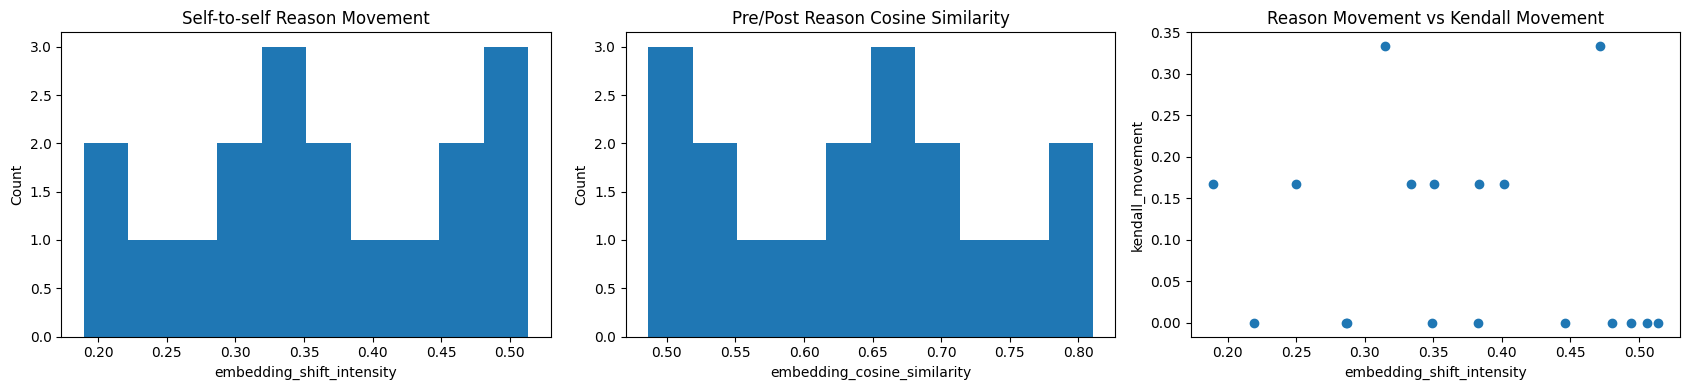

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].hist(participant_metrics_df['embedding_shift_intensity'].dropna(), bins=10)
axes[0].set_title('Self-to-self Reason Movement')
axes[0].set_xlabel('embedding_shift_intensity')
axes[0].set_ylabel('Count')

axes[1].hist(participant_metrics_df['embedding_cosine_similarity'].dropna(), bins=10)
axes[1].set_title('Pre/Post Reason Cosine Similarity')
axes[1].set_xlabel('embedding_cosine_similarity')
axes[1].set_ylabel('Count')

scatter_df = participant_metrics_df.dropna(subset=['embedding_shift_intensity', 'kendall_movement'])
axes[2].scatter(scatter_df['embedding_shift_intensity'], scatter_df['kendall_movement'])
axes[2].set_title('Reason Movement vs Kendall Movement')
axes[2].set_xlabel('embedding_shift_intensity')
axes[2].set_ylabel('kendall_movement')

plt.tight_layout()
plt.show()


## Save Outputs

This writes:
- participant-level metrics CSV
- excluded rows CSV
- summary CSV and JSON


In [15]:
participant_out = OUTPUT_DIR / 'within_subject_participant_metrics.csv'
excluded_out = OUTPUT_DIR / 'within_subject_excluded_rows.csv'
summary_csv_out = OUTPUT_DIR / 'within_subject_summary.csv'
summary_json_out = OUTPUT_DIR / 'within_subject_summary.json'

participant_metrics_df.to_csv(participant_out, index=False)
excluded_df.to_csv(excluded_out, index=False)
summary_df.to_csv(summary_csv_out, index=False)

with open(summary_json_out, 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved:')
print(' -', participant_out)
print(' -', excluded_out)
print(' -', summary_csv_out)
print(' -', summary_json_out)


Saved:
 - analysis/output/power_calc/within_subject_participant_metrics.csv
 - analysis/output/power_calc/within_subject_excluded_rows.csv
 - analysis/output/power_calc/within_subject_summary.csv
 - analysis/output/power_calc/within_subject_summary.json
